In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.cm as cm
import matplotlib as mpl

def normalize(x, mu, std):
    # return x
    return (x - mu) / std

def create_data(chemprop_model_path, target_columns, scaler_dict, normalize_data=True):
    gold_data_path = os.path.join(chemprop_model_path, "test_full.csv")
    pred_data_path = os.path.join(chemprop_model_path, "test_unc.csv")
    gold_data = pd.read_csv(gold_data_path)
    pred_data = pd.read_csv(pred_data_path)
    # # normalization
    if normalize_data:
        for target in target_columns:
            mean, std = scaler_dict[target]
            pred_data[target] = [normalize(t, mean, std) for t in pred_data[target]]
            gold_data[target] = [normalize(t, mean, std) for t in gold_data[target]]
            pred_data[target+"_evidential_total_uncal_var"] = [t/(std**2) for t in pred_data[target+"_evidential_total_uncal_var"]]

    rename_dict = {target: target+" prediction" for target in target_columns}
    pred_data = pred_data.rename(columns=rename_dict).drop(["smiles"],axis=1)
    return pd.concat([gold_data, pred_data], axis = 1)

def create_plot(data, target_columns, dataset):
    save_dir = "docs/plot_parity/{}".format(dataset)
    os.makedirs(save_dir, exist_ok=True)
    for target in target_columns:
        min_point = min(min(data[target]), min(data[target+" prediction"]))
        max_point = max(max(data[target]), max(data[target+" prediction"]))
        points = np.linspace(min_point,max_point,20)
        rmse = np.sqrt(mean_squared_error(data[target], data[target+" prediction"]))
        mae = mean_absolute_error(data[target], data[target+" prediction"])
        r2 = r2_score(data[target], data[target+" prediction"])
        print("RMSE, MAE, R2 score")
        print("{:.3f}, {:.3f}, {:.3f}".format(rmse, mae, r2))
        plt.figure(figsize=(4.5,4.5), dpi=100)
        plt.plot(points, points, color='black', linestyle='--')
        # plt.scatter(x=data[target], y=data[target+" prediction"])
        sns.scatterplot(data=data, x=target, y=target+" prediction")
        plt.xlabel("normalized "+target+" (-)", fontsize=14)
        plt.ylabel(target+" prediction"+" (-)", fontsize=14)
        plt.text(0.1, 0.9, r'$R^2$ = ' + f'{r2:.3f}', transform=plt.gca().transAxes, fontsize=13)
        plt.savefig(os.path.join(save_dir, "{}.svg".format(target)), format="svg", bbox_inches='tight')

def truncate_unc(data, target_columns, trunc_values):
    data_copy = data.copy()
    for target, trunc_value in zip(target_columns, trunc_values):
        var_name = target + "_evidential_total_uncal_var"
        new_values = [trunc_value if v > trunc_value else v for v in data[var_name]]
        data_copy[var_name] = new_values
    return data_copy


def create_unc_plot(data, target_columns, dataset):
    cmap = cm.viridis
    save_dir = "docs/plot_parity_unc/{}".format(dataset)
    os.makedirs(save_dir, exist_ok=True)
    
    for j, target in enumerate(target_columns):
        var_name = target + "_evidential_total_uncal_var"

        min_point = min(min(data[target]), min(data[target+" prediction"]))
        max_point = max(max(data[target]), max(data[target+" prediction"]))
        points = np.linspace(min_point,max_point,20)
        rmse = np.sqrt(mean_squared_error(data[target], data[target+" prediction"]))
        mae = mean_absolute_error(data[target], data[target+" prediction"])
        r2 = r2_score(data[target], data[target+" prediction"])
        print("RMSE, MAE, R2 score")
        print("{:.3f}, {:.3f}, {:.3f}".format(rmse, mae, r2))

        fig = plt.figure(figsize=(4.5,4.5), dpi=80)
        plt.plot(points, points, color='black', linestyle='--')
        # plt.scatter(x=data[target], y=data[target+" prediction"])
        sns.scatterplot(data=data.sort_values(by = var_name, axis = 0,ascending=False),
                         x=target, y=target+" prediction", hue=var_name, palette=cmap, legend=False,
                         s=10, alpha=0.65)
        plt.xlabel("Normalized "+target+" (-)", fontsize=14)
        plt.ylabel("Normalized "+target+" prediction"+" (-)", fontsize=14)
        plt.text(0.1, 0.9, r'$R^2$ = ' + f'{r2:.3f}', transform=plt.gca().transAxes, fontsize=13)

        if j == len(target_columns)-1:
            norm = mpl.colors.Normalize(vmin=min(data[var_name]), vmax=max(data[var_name]))
            cax = fig.add_axes([0.91, 0.107, 0.065, 0.77])
            cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax, orientation='vertical',
                                label='Normalized model uncertainty variance')
            cbar.set_label(label='Normalized model uncertainty variance',size=13)
        plt.savefig(os.path.join(save_dir, "{}.svg".format(target)), format="svg", bbox_inches='tight')
        # break
# plt.show()

## Organic Emitters

RMSE, MAE, R2 score
0.317, 0.205, 0.898
RMSE, MAE, R2 score
0.499, 0.216, 0.743
RMSE, MAE, R2 score
0.347, 0.223, 0.879


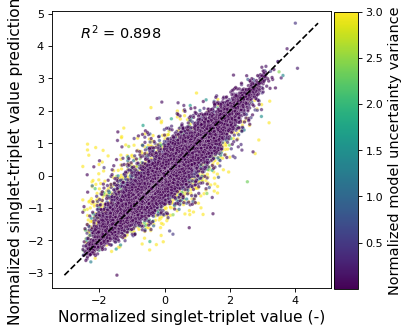

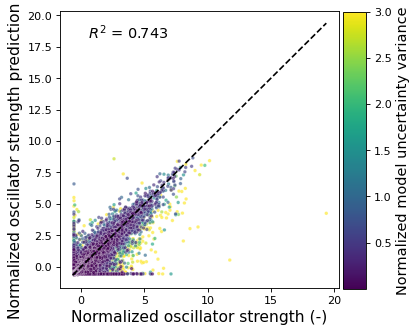

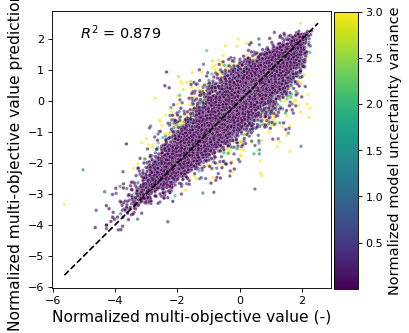

In [10]:
scaler_dict = {"singlet-triplet value": (1.003, 0.396), "oscillator strength": (0.086, 0.149), "multi-objective value": (-1.6, 0.65)}
target_columns = ["singlet-triplet value", "oscillator strength", "multi-objective value"]
models_path = ["chemprop_unc/save_models/organic_emitter/st_15p/fold_0",
               "chemprop_unc/save_models/organic_emitter/os_01p/fold_0",
               "chemprop_unc/save_models/organic_emitter/mo_10p/fold_0"]
dataset = "organic_emitter"

for subtarget, model_path in zip(target_columns, models_path):
    data = create_data(model_path, [subtarget], scaler_dict)
    trunc_values = (3, 3, 3)
    data_new = truncate_unc(data, [subtarget], trunc_values)
    create_unc_plot(data_new, [subtarget], dataset)


RMSE, MAE, R2 score
0.319, 0.207, 0.897
RMSE, MAE, R2 score
0.499, 0.216, 0.743
RMSE, MAE, R2 score
0.345, 0.224, 0.881


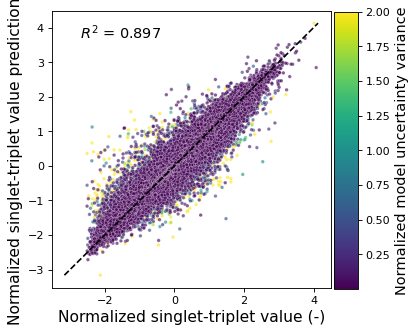

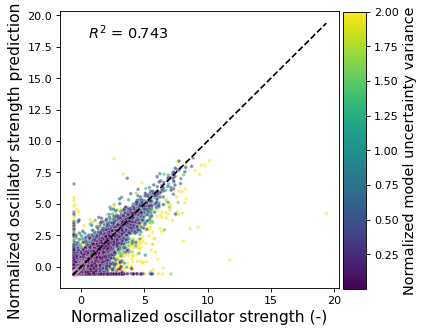

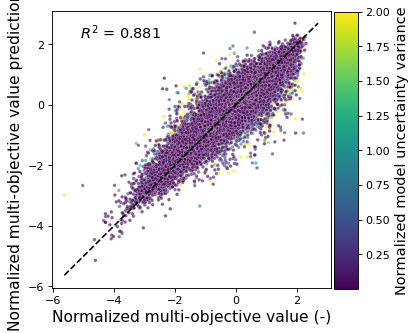

In [6]:
scaler_dict = {"singlet-triplet value": (1.003, 0.396), "oscillator strength": (0.086, 0.149), "multi-objective value": (-1.6, 0.65)}
target_columns = ["singlet-triplet value", "oscillator strength", "multi-objective value"]
models_path = ["chemprop_unc/save_models/organic_emitter/st_10p/fold_0",
               "chemprop_unc/save_models/organic_emitter/os_01p/fold_0",
               "chemprop_unc/save_models/organic_emitter/mo_5p/fold_0"]
dataset = "organic_emitter"

for subtarget, model_path in zip(target_columns, models_path):
    data = create_data(model_path, [subtarget], scaler_dict)
    trunc_values = (2, 2, 2)
    data_new = truncate_unc(data, [subtarget], trunc_values)
    create_unc_plot(data_new, [subtarget], dataset)
